<a href="https://colab.research.google.com/github/jeolin/BCCE_Experiment/blob/main/Dynamic_Synthetic_Data_Based_on_R_Squared.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Purpose of this Experimental Code

This notebook contains experimental code designed to simulate a spectroscopy experiment, specifically in the context of Beer's Law analysis. The primary goal is to illustrate how the choice of an analytical wavelength (lambda max) can impact the quality of a calibration curve, as quantified by the R-squared value.

In a real-world scenario, students performing a Beer's Law experiment would select a wavelength for analysis. If they choose a wavelength with a strong absorbance (close to the true lambda max), their data points for a calibration curve should yield a very high R-squared value, indicating a strong linear relationship. Conversely, if they select a wavelength with low absorbance, the signal-to-noise ratio decreases, leading to noisier data and consequently a lower R-squared value for their calibration curve.

The `signal_strength` variable in this code represents the proportional absorbance at a chosen wavelength, calculated as $A_{lambda} / A_{max}$. This variable directly influences the expected R-squared range for the simulated data:

*   **High `signal_strength` (e.g., >= 0.6):** Corresponds to selecting an optimal wavelength, resulting in a high R-squared value (e.g., 0.960 to 0.999).
*   **Low `signal_strength` (e.g., >= 0.2):** Corresponds to selecting a suboptimal wavelength, leading to a lower R-squared value (e.g., 0.8 to 0.9).
*   **Very Low `signal_strength` (e.g., >= 0):** Represents a poor wavelength choice, yielding a significantly lower R-squared value (e.g., 0.5 to 0.7).

The code dynamically generates synthetic 'x' and 'y' data points, adding varying levels of noise based on the `signal_strength`, to achieve an R-squared value within the specified target range. This demonstrates the relationship between signal quality (simulated by `signal_strength`) and the statistical fit of a linear model (R-squared) in a practical experimental context.

Generated DataFrame:


,x,y
0,0,0.000000
1,1,3.680937
2,2,4.311968
3,3,4.465306
4,4,4.519525



--- Summary of Key Variables ---
Signal Strength: 0.12
Minimum acceptable R-squared: 0.500
Maximum acceptable R-squared: 0.700
Current data R-squared: 0.649
----------------------------------


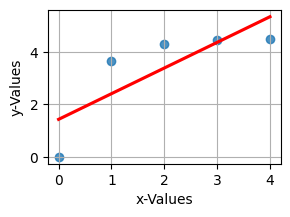

In [2]:
signal_strength=0.12

# Determine target R-squared and range based on signal_strength
if signal_strength >= 0.6:
    # Best wavelength choice: r-squared is random value between 0.960 and 0.999
    lower_bound_r_squared = 0.96
    upper_bound_r_squared = 1.00
elif signal_strength >= 0.4:
    # Good choice: r-squared is random between 0.95 and 0.9799
    lower_bound_r_squared = 0.92
    upper_bound_r_squared = 0.95
elif signal_strength >= 0.2:
    # Acceptable choice: r-squared is random between 0.8 and 0.9
    lower_bound_r_squared = 0.8
    upper_bound_r_squared = 0.9
elif signal_strength >= 0:
    # Poor choice: r-squared is random between 0.5 and 0.6599
    lower_bound_r_squared = 0.5
    upper_bound_r_squared = 0.7
else:
    # Default to a low R-squared if signal_strength is outside defined ranges
    lower_bound_r_squared = 0.2
    upper_bound_r_squared = 0.4

target_r_squared = (lower_bound_r_squared + upper_bound_r_squared) / 2

import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns

# Define x-values
x_values = np.array([0, 1, 2, 3, 4])

# 1. Define the ideal linear relationship (passing through (0,0))
# We assume an underlying true relationship of y = x
y_base = x_values

# The acceptable R-squared range is now directly defined by lower_bound_r_squared and upper_bound_r_squared

r_squared_actual = -1.0 # Initialize to ensure loop runs
max_iterations = 2000 # Safety break for the loop
iteration = 0

# Store the best approximation found
best_r_squared_diff = float('inf')
best_y_values = None

# Initial scale for random noise (will be adjusted dynamically)
noise_scale = 0.1

while not (lower_bound_r_squared <= r_squared_actual <= upper_bound_r_squared) and iteration < max_iterations:
    iteration += 1

    # Generate random noise (residuals), ensuring the first one is 0
    residuals = np.random.normal(loc=0, scale=1, size=len(x_values))
    residuals[0] = 0

    # Apply the current noise_scale to the residuals
    y_values_current = y_base + residuals * noise_scale

    # Calculate R-squared for the current y_values
    slope, intercept, r_value, p_value, std_err = linregress(x_values, y_values_current)
    r_squared_actual = r_value**2

    # Check if we are within the target range
    if lower_bound_r_squared <= r_squared_actual <= upper_bound_r_squared:
        best_y_values = y_values_current.copy()
        break # Exit loop, we found a good set of y_values

    # Keep track of the closest R-squared found so far
    current_r_squared_diff = abs(r_squared_actual - target_r_squared)
    if current_r_squared_diff < best_r_squared_diff:
        best_r_squared_diff = current_r_squared_diff
        best_y_values = y_values_current.copy()

    # Adjust noise_scale for the next iteration based on current R-squared
    # If R-squared is too high, it means there's not enough noise; increase noise_scale.
    # If R-squared is too low, it means there's too much noise; decrease noise_scale.
    if r_squared_actual > upper_bound_r_squared:
        noise_scale *= 1.1 # Increase noise_scale to add more noise
    elif r_squared_actual < lower_bound_r_squared:
        noise_scale *= 0.9 # Decrease noise_scale to add less noise

# Use the best set of y_values found
if best_y_values is None: # Fallback in case no valid y_values were ever generated
    y_values = y_base # Default to perfect fit if nothing worked
    r_squared = 1.0
    print("Error: Could not generate data within the target R-squared range. Defaulting to perfect fit.")
else:
    y_values = best_y_values
    # Recalculate R-squared for the final chosen y_values to ensure accuracy
    slope, intercept, r_value, p_value, std_err = linregress(x_values, y_values)
    r_squared = r_value**2

# Create a DataFrame
df = pd.DataFrame({'x': x_values, 'y': y_values})

print("Generated DataFrame:")
display(df)

if iteration >= max_iterations:
    print(f"Warning: Max iterations reached ({max_iterations}) without achieving R-squared in target range [{lower_bound_r_squared:.3f}, {upper_bound_r_squared:.3f}]. Best R-squared found: {np.around(r_squared, 3)}")

# Summary of key variables
print(f"\n--- Summary of Key Variables ---")
print(f"Signal Strength: {signal_strength:.2f}")
print(f"Minimum acceptable R-squared: {lower_bound_r_squared:.3f}")
print(f"Maximum acceptable R-squared: {upper_bound_r_squared:.3f}")
print(f"Current data R-squared: {r_squared:.3f}")
print(f"----------------------------------")

# Generate a simple graph
plt.figure(figsize=(3, 2))
sns.regplot(x='x', y='y', data=df, ci=None, line_kws={'color': 'red'})
plt.xlabel('x-Values')
plt.ylabel('y-Values')
plt.grid(True)
plt.show()